## Notebook for visualizing results from sequential implementation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys
import jax.numpy as jnp
import jax
import json
import os

from NRT_functions import losses
from NRT_functions import helper_functions
from NRT_functions import plotters
from sweep_analysis_sequential import generate_2d_plots, generate_loss_plots

In [ ]:
filepath = './data/260113/sweep_104746/run012'
counter = 0
save_fig = 0
plot_scale = 1

if counter == '':
    adding_string = ''
else:
    adding_string = '_'

%cd "$filepath"

# Load parameters
with open('parameters.json', 'r') as json_file:
    parameters = json.load(json_file)

# Load g0 (activity at origin) instead of W
with open('g0' + adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    g0 = pickle.load(pickle_file)

# Load frequencies
with open('om'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    om = pickle.load(pickle_file)

# Load transformation matrix S
with open('S'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    S = pickle.load(pickle_file)

# Load losses
with open('min_L'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    min_L = pickle.load(pickle_file)

with open('L'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    L = pickle.load(pickle_file)

# Load initial values
with open('g0_init'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    g0_init = pickle.load(pickle_file)

with open('S_init'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    S_init = pickle.load(pickle_file)

# Load final values
try:
    with open('g0_final'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
        g0_final = pickle.load(pickle_file)
except:
    g0_final = g0

try:
    with open('S_final'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
        S_final = pickle.load(pickle_file)
except:
    S_final = S

# Use final values if min loss is poor
# if min_L[0] < 1:
g0 = g0_final
S = S_final

# Compute D from g0 shape
D = g0.shape[0]
M = int((D - 1) / 2)

print(f"Loaded optimization results:")
print(f"  D = {D}, M = {M}")
print(f"  g0 shape: {g0.shape}")
print(f"  S shape: {S.shape}")
print(f"  om shape: {om.shape}")
print(f"  Min loss: {min_L[1]:.5f}")

In [ ]:
# Visualize 2D plane results using generate_2d_plots from sweep_analysis_sequential
if parameters["dim"] == 2:
    # Get current directory for savepath
    savepath = os.getcwd()
    
    # Generate all 2D plots using the imported function
    figures = generate_2d_plots(g0, om, S, parameters, savepath, counter, plot_scale)
    
    # Display the figures
    for fig_name, fig in figures.items():
        plt.figure(fig.number)
        plt.show()

In [ ]:
# Plot the loss curves using generate_loss_plots from sweep_analysis_sequential
# Load lambda arrays if they exist
try:
    with open('lambda_pos' + adding_string + f'{counter}.pkl', 'rb') as pickle_file:
        lambda_pos = pickle.load(pickle_file)
except:
    lambda_pos = None

try:
    with open('lambda_norm' + adding_string + f'{counter}.pkl', 'rb') as pickle_file:
        lambda_norm = pickle.load(pickle_file)
except:
    lambda_norm = None

fig_loss = generate_loss_plots(L, min_L, lambda_pos, lambda_norm)
plt.show()

In [ ]:
# Regenerate loss plots with validation losses
try:
    with open('val_L' + adding_string + f'{counter}.pkl', 'rb') as pickle_file:
        val_L = pickle.load(pickle_file)
    print(f"Loaded validation loss array with shape: {val_L.shape}")
    
    fig_loss_with_val = generate_loss_plots(L, min_L, lambda_pos, lambda_norm, val_L=val_L)
    plt.show()
except FileNotFoundError:
    print("No validation loss file (val_L*.pkl) found - skipping validation loss plot")

In [ ]:
from NRT_functions.analysis import quantitative_analysis_seq

fig_score = quantitative_analysis_seq(g0, S, om, parameters, counter, savepath=os.getcwd())

In [ ]:
# Analyze S matrix structure
print("\nAnalysis of S (change of basis matrix):")
print(f"  Shape: {S.shape}")
print(f"  Frobenius norm: {np.linalg.norm(S):.5f}")
print(f"  Condition number: {np.linalg.cond(S):.5f}")
print(f"  Determinant: {np.linalg.det(S):.5f}")

# Note: S matrix visualization is generated by generate_2d_plots() above

In [3]:
from DataHandling import TrajectoryGenerator

generator = TrajectoryGenerator()
generator.generate_validation_dataset('dataset/validation/', 'random', box_sizes=[(2,2), (5,5)], num_batches=10)

Generating random validation data for box size (2, 2)...
  Sequence length: 100
  Generated 10/10 batches
  Saved to dataset/validation/random_box2x2
Generating random validation data for box size (5, 5)...
  Sequence length: 100
  Generated 10/10 batches
  Saved to dataset/validation/random_box5x5

Validation dataset generation complete!
Total configurations: 2
Total samples per config: 100


['dataset/validation/random_box2x2', 'dataset/validation/random_box5x5']

# Re-run analysis for sweep

In [4]:
import os
import json
import matplotlib.pyplot as plt
from sweep_analysis_sequential import generate_analysis_plots

sweep_path = "data/260116/constant_n_per_step_1000_varied_data/"
run_dirs = sorted([
    d for d in os.listdir(sweep_path)
    if d.startswith('run') and os.path.isdir(os.path.join(sweep_path, d))
])

for run_dir in run_dirs:
    run_savepath = os.path.join(sweep_path, run_dir)
    with open(os.path.join(run_savepath, 'parameters.json'), 'r') as f:
        run_parameters = json.load(f)
    
    for k in range(run_parameters["K"]):
        try:
            figs = generate_analysis_plots(run_savepath, counter=k)
            plt.close('all')
        except Exception as e:
            print(f"  Warning: Failed to generate analysis plots for {run_dir} k={k}: {e}")

  0%|          | 0/65 [00:00<?, ?it/s]/home/julian/Projects/MasterThesis/ICLR_Actionable_Reps/scores.py:126: RuntimeWarning: invalid value encountered in power
  std_seq1 = np.power(
/home/julian/Projects/MasterThesis/ICLR_Actionable_Reps/scores.py:130: RuntimeWarning: invalid value encountered in power
  std_seq2 = np.power(
 60%|██████    | 39/65 [00:12<00:08,  3.22it/s]/home/julian/Projects/MasterThesis/ICLR_Actionable_Reps/scores.py:137: RuntimeWarning: divide by zero encountered in divide
  x_coef = np.divide(covar, np.multiply(std_seq1, std_seq2))
  0%|          | 0/65 [00:00<?, ?it/s]/home/julian/Projects/MasterThesis/ICLR_Actionable_Reps/scores.py:137: RuntimeWarning: invalid value encountered in divide
  x_coef = np.divide(covar, np.multiply(std_seq1, std_seq2))
100%|██████████| 65/65 [00:20<00:00,  3.22it/s]


In [7]:
# Regenerate loss plots with validation losses for all runs in sweep
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sweep_analysis_sequential import generate_loss_plots

sweep_path = "data/260116/constant_n_per_step_1000_varied_data/"
run_dirs = sorted([
    d for d in os.listdir(sweep_path)
    if d.startswith('run') and os.path.isdir(os.path.join(sweep_path, d))
])

for run_dir in run_dirs:
    run_savepath = os.path.join(sweep_path, run_dir)
    with open(os.path.join(run_savepath, 'parameters.json'), 'r') as f:
        run_parameters = json.load(f)
    
    # Load validation losses from JSON
    val_losses_path = os.path.join(run_savepath, 'validation_losses.json')
    if not os.path.exists(val_losses_path):
        print(f"  {run_dir}: No validation_losses.json found, skipping")
        continue
    
    with open(val_losses_path, 'r') as f:
        val_losses = json.load(f)
    
    for k in range(run_parameters["K"]):
        try:
            # Load training losses
            with open(os.path.join(run_savepath, f'L_{k}.pkl'), 'rb') as f:
                L = pickle.load(f)
            with open(os.path.join(run_savepath, f'min_L_{k}.pkl'), 'rb') as f:
                min_L = pickle.load(f)
            
            # Load lambda arrays if they exist
            try:
                with open(os.path.join(run_savepath, f'lambda_pos_{k}.pkl'), 'rb') as f:
                    lambda_pos = pickle.load(f)
            except FileNotFoundError:
                lambda_pos = None
            
            try:
                with open(os.path.join(run_savepath, f'lambda_norm_{k}.pkl'), 'rb') as f:
                    lambda_norm = pickle.load(f)
            except FileNotFoundError:
                lambda_norm = None
            
            # Extract validation losses for this k from JSON
            # mean_across_datasets has shape [4][n_steps], convert to [4, n_steps]
            k_str = str(k)
            if k_str not in val_losses['per_k']:
                print(f"  {run_dir} k={k}: No validation data for k={k}, skipping")
                continue
            
            val_L = np.array(val_losses['per_k'][k_str]['mean_across_datasets'])
            
            # Generate and save the plot
            fig_loss = generate_loss_plots(L, min_L, lambda_pos, lambda_norm, val_L=val_L)
            fig_loss.savefig(os.path.join(run_savepath, f'loss_with_val_{k}.png'), dpi=150, bbox_inches='tight')
            plt.close(fig_loss)
            print(f"  {run_dir} k={k}: Saved loss_with_val_{k}.png")
            
        except Exception as e:
            print(f"  Warning: Failed for {run_dir} k={k}: {e}")

  run000 k=0: Saved loss_with_val_0.png
  run000 k=1: Saved loss_with_val_1.png
  run000 k=2: Saved loss_with_val_2.png
  run000 k=3: Saved loss_with_val_3.png
  run000 k=4: Saved loss_with_val_4.png
  run001 k=0: Saved loss_with_val_0.png
  run001 k=1: Saved loss_with_val_1.png
  run001 k=2: Saved loss_with_val_2.png
  run001 k=3: Saved loss_with_val_3.png
  run001 k=4: Saved loss_with_val_4.png
  run002 k=0: Saved loss_with_val_0.png
  run002 k=1: Saved loss_with_val_1.png
  run002 k=2: Saved loss_with_val_2.png
  run002 k=3: Saved loss_with_val_3.png
  run002 k=4: Saved loss_with_val_4.png
  run003 k=0: Saved loss_with_val_0.png
  run003 k=1: Saved loss_with_val_1.png
  run003 k=2: Saved loss_with_val_2.png
  run003 k=3: Saved loss_with_val_3.png
  run003 k=4: Saved loss_with_val_4.png
  run004 k=0: Saved loss_with_val_0.png
  run004 k=1: Saved loss_with_val_1.png
  run004 k=2: Saved loss_with_val_2.png
  run004 k=3: Saved loss_with_val_3.png
  run004 k=4: Saved loss_with_val_4.png


## Distribution of mean/max scores over runs

Score distribution plots saved to data/260116/constant_n_per_step_1000_varied_data/


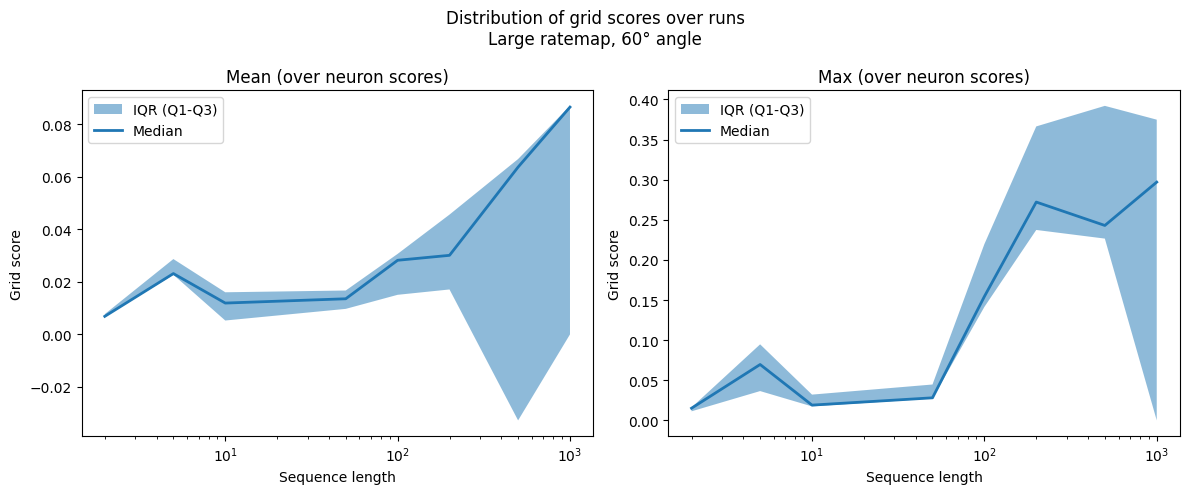

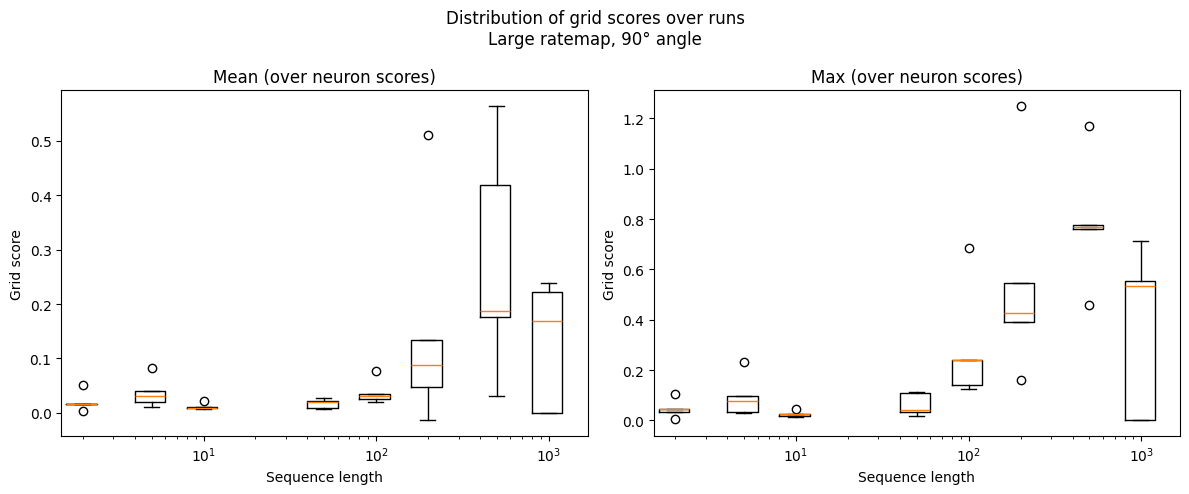

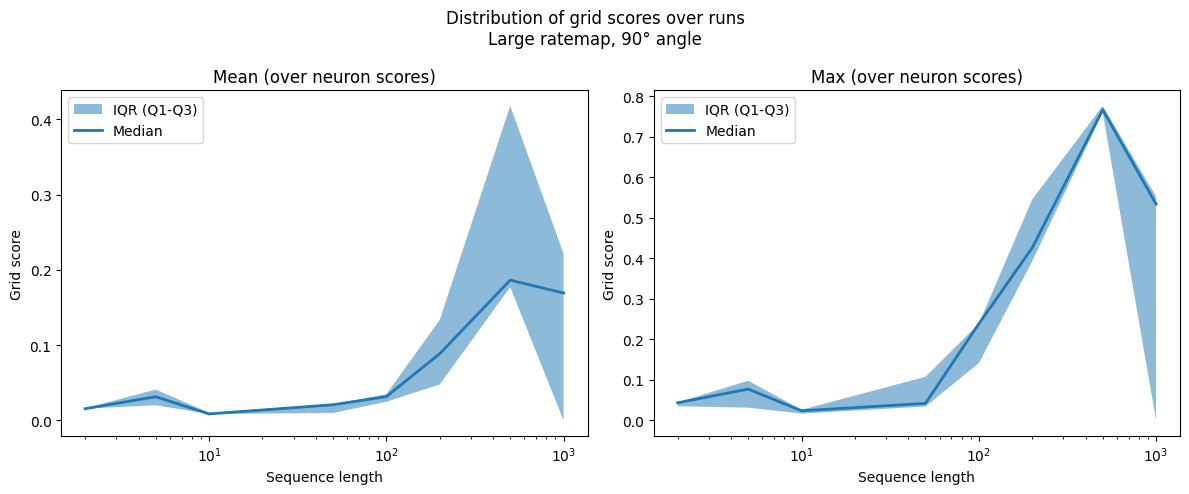

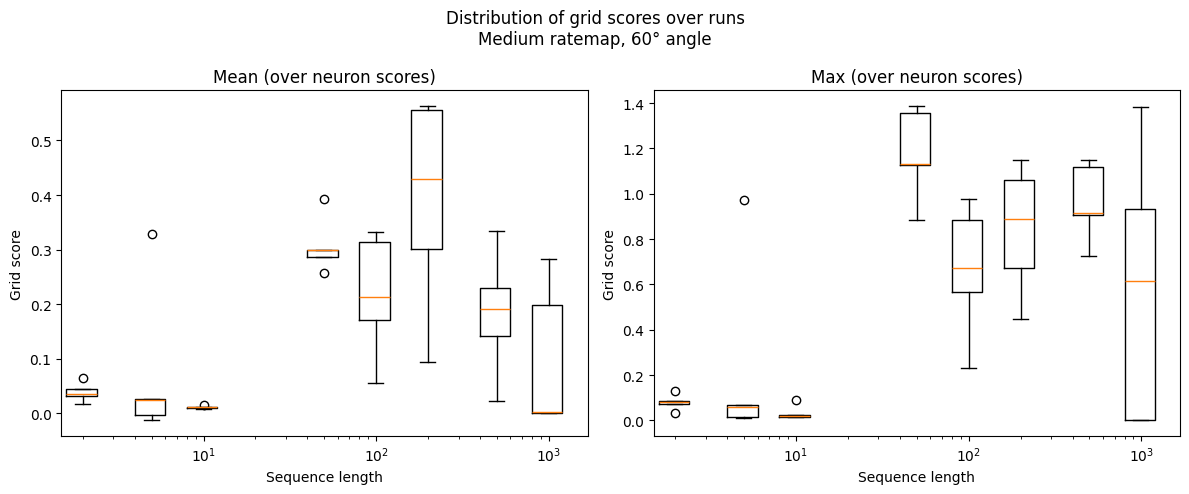

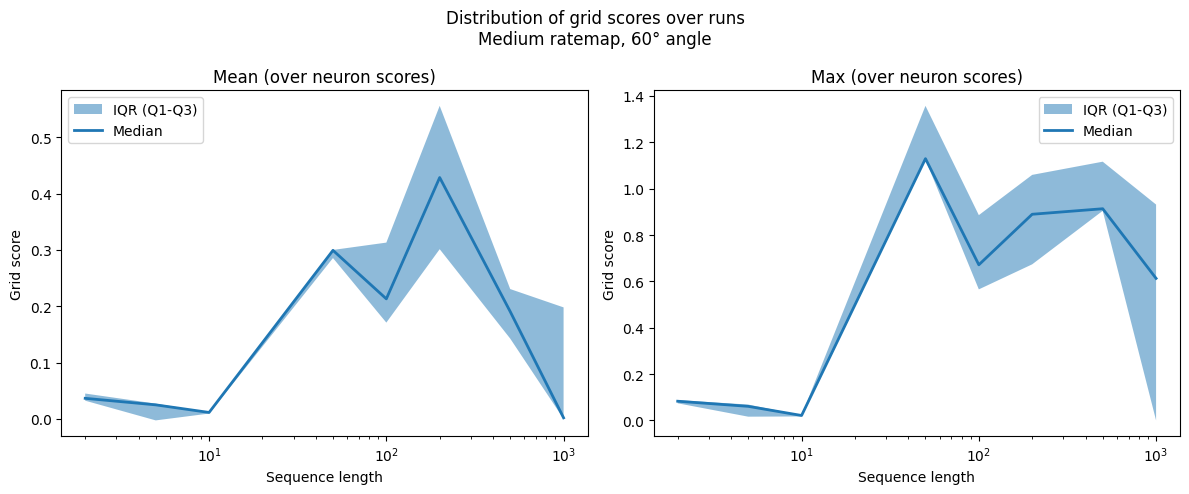

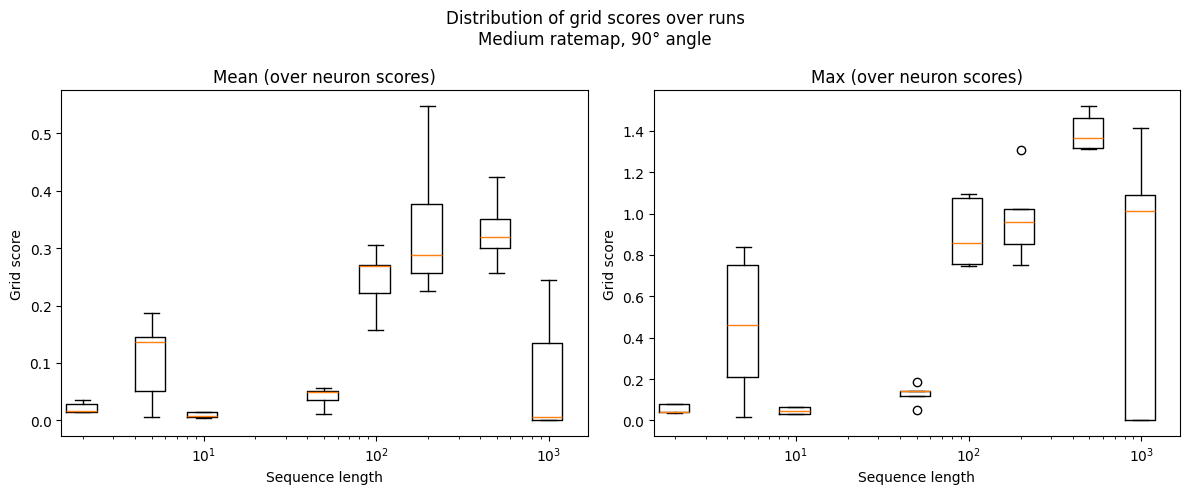

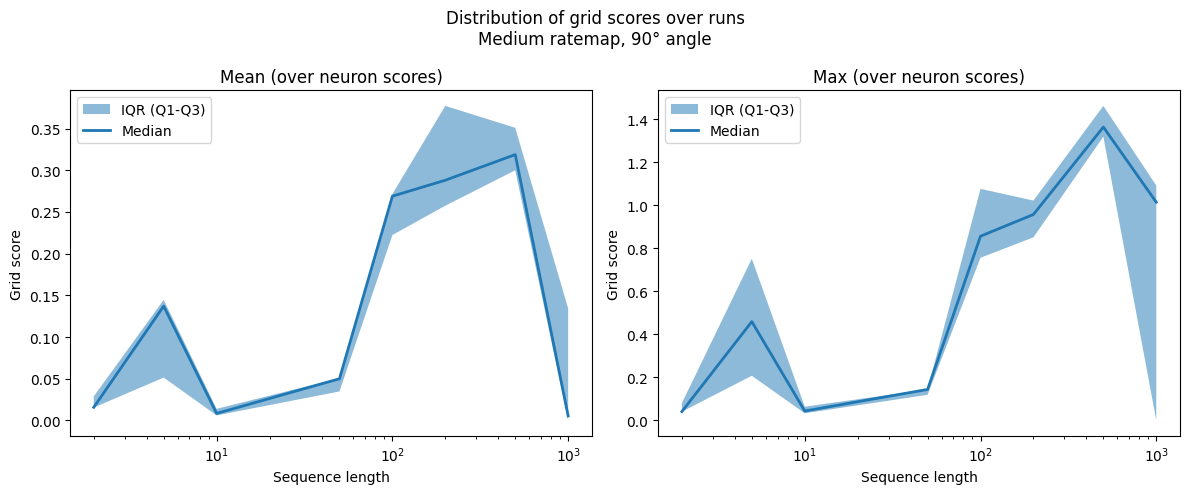

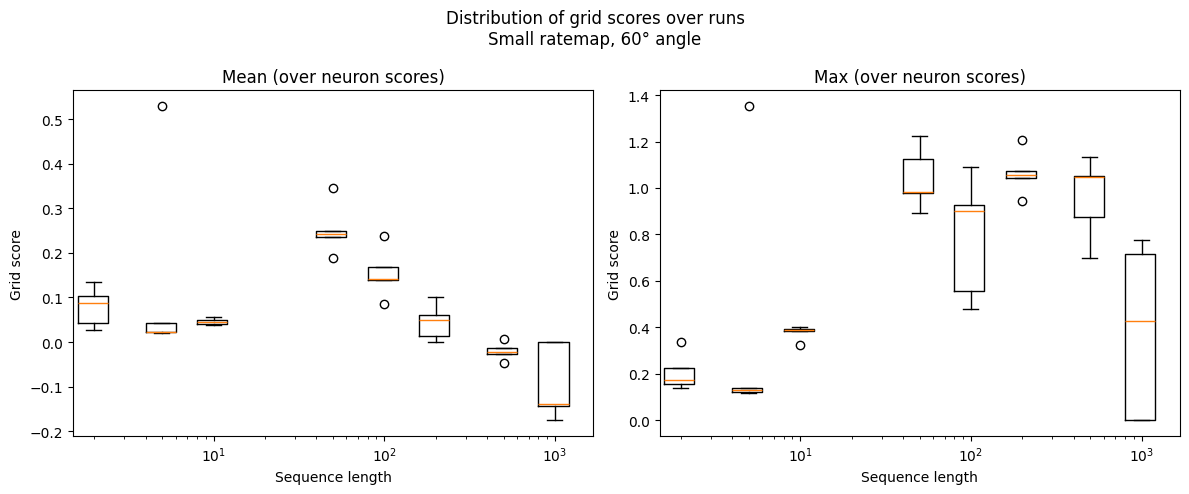

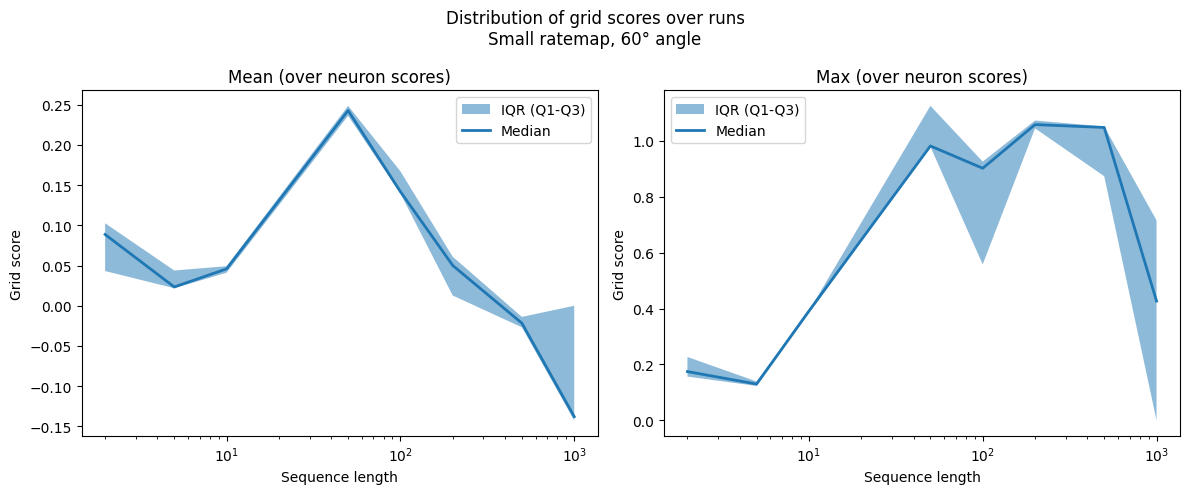

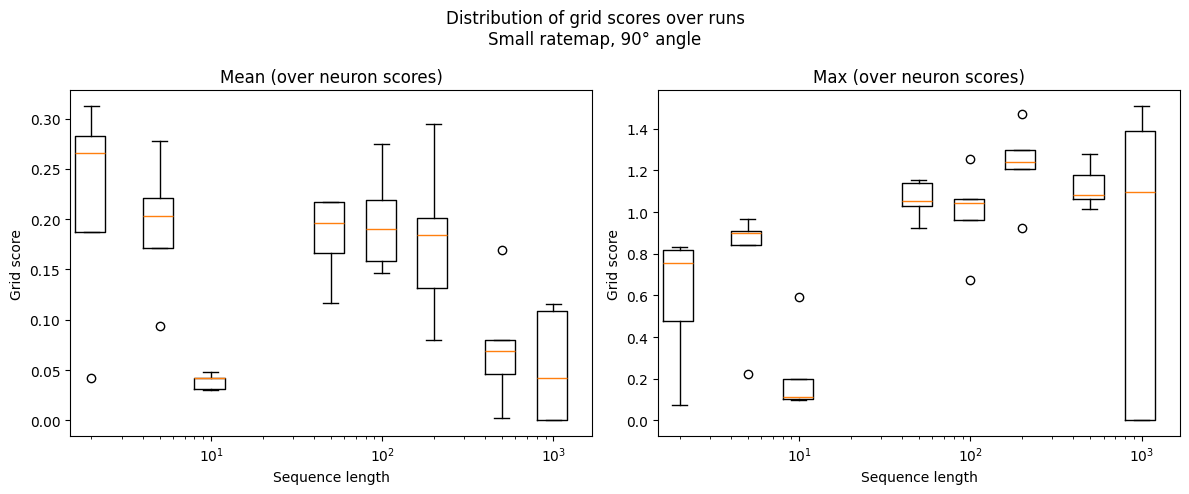

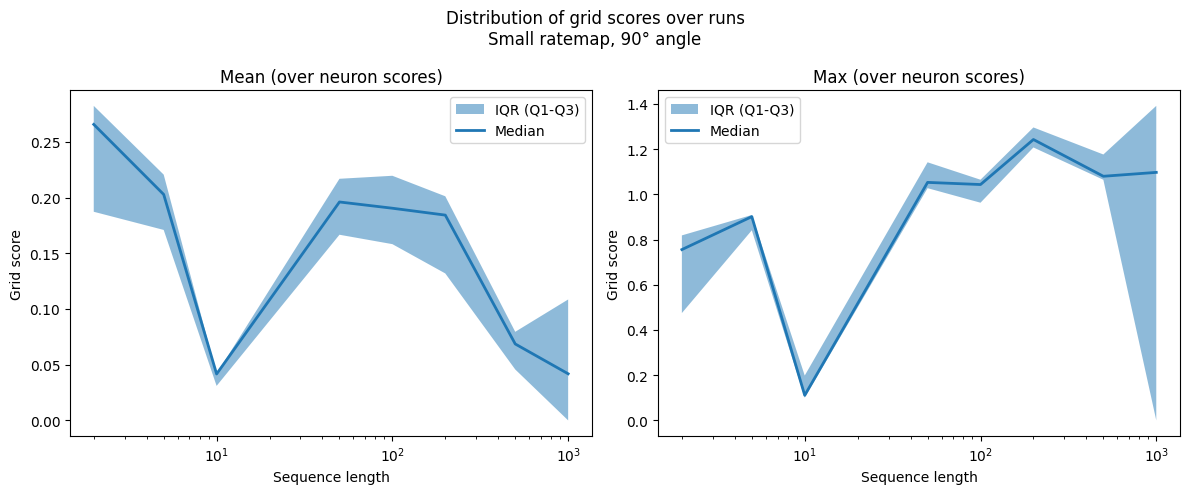

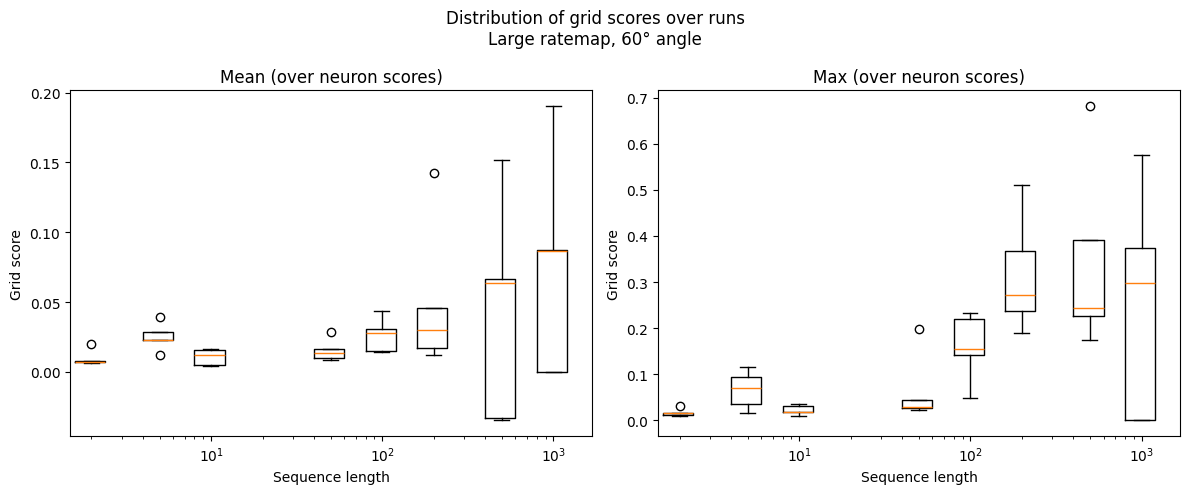

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [5]:
from sweep_analysis_sequential import generate_sweep_score_distributions

sweep_path = "data/260116/constant_n_per_step_1000_varied_data/"

figures = generate_sweep_score_distributions(sweep_path)

# Display all figures
for fig_name, fig in figures.items():
    plt.figure(fig.number)
    plt.show()

Validation loss distribution plots saved to data/260116/constant_n_per_step_1000_varied_data/


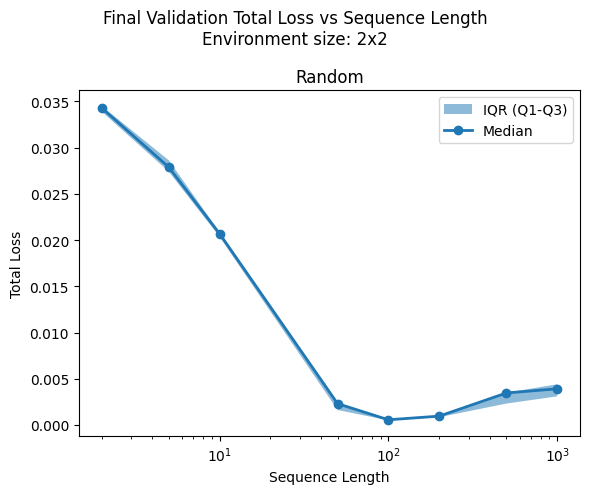

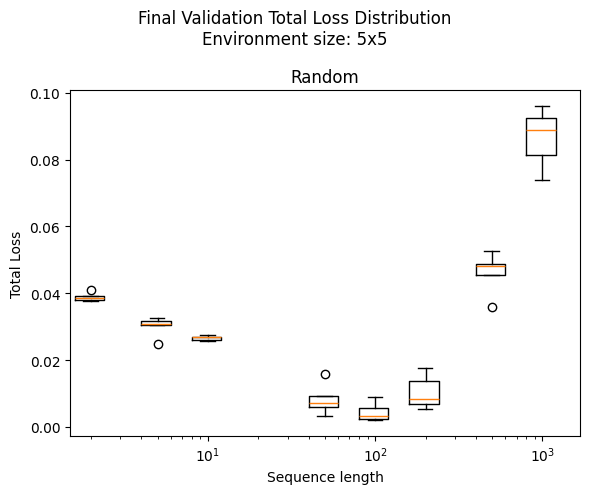

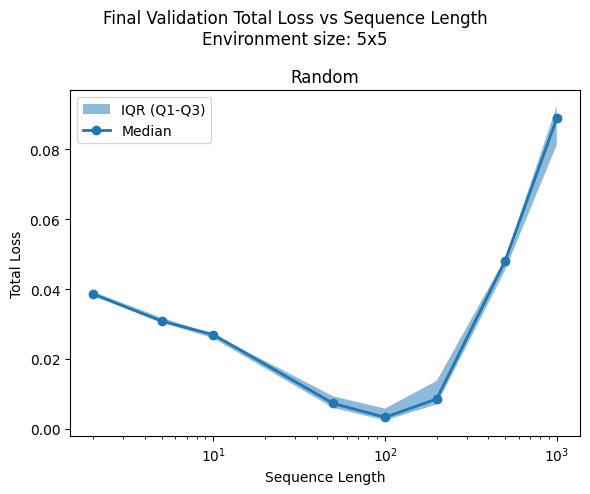

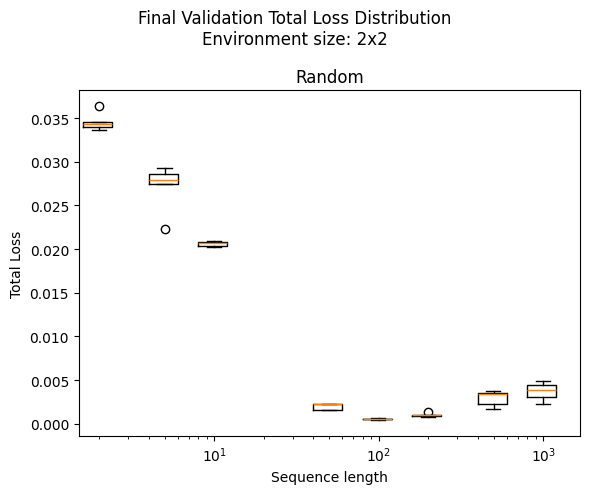

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [6]:
# Compare validation losses across environments
from sweep_analysis_sequential import generate_sweep_validation_loss_distributions
import matplotlib.pyplot as plt

sweep_path = "data/260116/constant_n_per_step_1000_varied_data/"

# Generate comparison plots for total loss (loss_component=0)
figures = generate_sweep_validation_loss_distributions(
    sweep_path,
    use_final=True,  # Use final step losses (set to False for best/minimum)
    loss_component=0  # 0=total, 1=separation, 2=positivity, 3=norm
)

# Display all figures
for fig_name, fig in figures.items():
    plt.figure(fig.number)
    plt.show()

## Compute validation losses for sweep runs

In [4]:
import os
import json
import numpy as np
from sweep_analysis_sequential import compute_validation_losses

def convert_to_json_serializable(obj):
    """Recursively convert numpy arrays and other non-serializable types to JSON-compatible format."""
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    elif isinstance(obj, dict):
        return {str(k): convert_to_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [convert_to_json_serializable(item) for item in obj]
    else:
        return obj

def compute_validation_losses_for_sweep(
    sweep_path: str,
    validation_path: str = "dataset/validation",
    use_best_checkpoints: bool = False,
    skip_existing: bool = True
):
    """
    Compute validation losses for all runs in a sweep directory.
    
    Args:
        sweep_path: Path to the sweep directory containing run subdirectories
        validation_path: Path to directory containing validation datasets
        use_best_checkpoints: If True, use g0_best_step_*.pkl etc.
        skip_existing: If True, skip runs that already have validation_losses.json
    """
    # Find all run directories
    run_dirs = sorted([
        d for d in os.listdir(sweep_path)
        if d.startswith('run') and os.path.isdir(os.path.join(sweep_path, d))
    ])
    
    if not run_dirs:
        print(f"No run directories found in {sweep_path}")
        return
    
    print(f"Found {len(run_dirs)} run directories in {sweep_path}")
    
    for idx, run_dir in enumerate(run_dirs):
        run_path = os.path.join(sweep_path, run_dir)
        output_file = os.path.join(run_path, 'validation_losses.json')
        
        # Check if already computed
        if skip_existing and os.path.exists(output_file):
            print(f"[{idx + 1}/{len(run_dirs)}] {run_dir}: Skipping (validation_losses.json exists)")
            continue
        
        print(f"\n[{idx + 1}/{len(run_dirs)}] Processing {run_dir}...")
        
        # Check if checkpoints directory exists
        checkpoints_path = os.path.join(run_path, "checkpoints")
        if not os.path.exists(checkpoints_path):
            print(f"  Skipping: No checkpoints directory found")
            continue
        
        try:
            # Compute validation losses
            results = compute_validation_losses(
                run_path=run_path,
                validation_path=validation_path,
                use_best_checkpoints=use_best_checkpoints
            )
            
            # Convert to JSON-serializable format
            results_serializable = convert_to_json_serializable(results)
            
            # Save to JSON
            with open(output_file, 'w') as f:
                json.dump(results_serializable, f, indent=2)
            
            print(f"  Saved validation losses to {output_file}")
            print(f"  Summary: Best step={results['summary']['best_step']}, "
                  f"Best loss={results['summary']['best_mean_loss']:.6f}")
            
        except Exception as e:
            print(f"  Error: {e}")
            continue
    
    print(f"\nValidation loss computation complete for sweep: {sweep_path}")

In [5]:
# Example usage: compute validation losses for all runs in a sweep
sweep_path = "data/260116/constant_n_per_step_1000_varied_data/"
validation_path = "dataset/validation"

compute_validation_losses_for_sweep(
    sweep_path=sweep_path,
    validation_path=validation_path,
    use_best_checkpoints=False,
    skip_existing=True  # Set to False to recompute existing
)

Found 8 run directories in data/260116/constant_n_per_step_1000_varied_data/

[1/8] Processing run000...
Found 2 validation datasets
Computing validation losses for 5 k values, 24 steps, 2 datasets...
    Step 200 (1/24)... done
    Step 400 (2/24)... done
    Step 600 (3/24)... done
    Step 800 (4/24)... done
    Step 1000 (5/24)... done
    Step 1200 (6/24)... done
    Step 1400 (7/24)... done
    Step 1600 (8/24)... done
    Step 1800 (9/24)... done
    Step 2000 (10/24)... done
    Step 2200 (11/24)... done
    Step 2400 (12/24)... done
    Step 2600 (13/24)... done
    Step 2800 (14/24)... done
    Step 3000 (15/24)... done
    Step 3200 (16/24)... done
    Step 3400 (17/24)... done
    Step 3600 (18/24)... done
    Step 3800 (19/24)... done
    Step 4000 (20/24)... done
    Step 4200 (21/24)... done
    Step 4400 (22/24)... done
    Step 4600 (23/24)... done
    Step 4800 (24/24)... done
  k=0 done
    Step 200 (1/24)... done
    Step 400 (2/24)... done
    Step 600 (3/24)... do

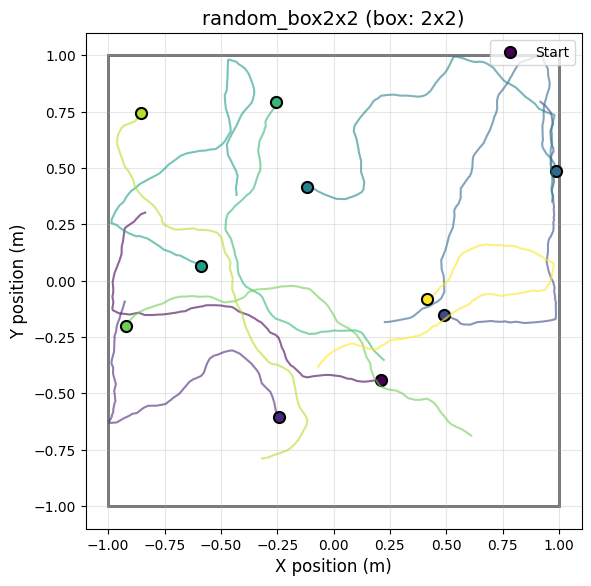

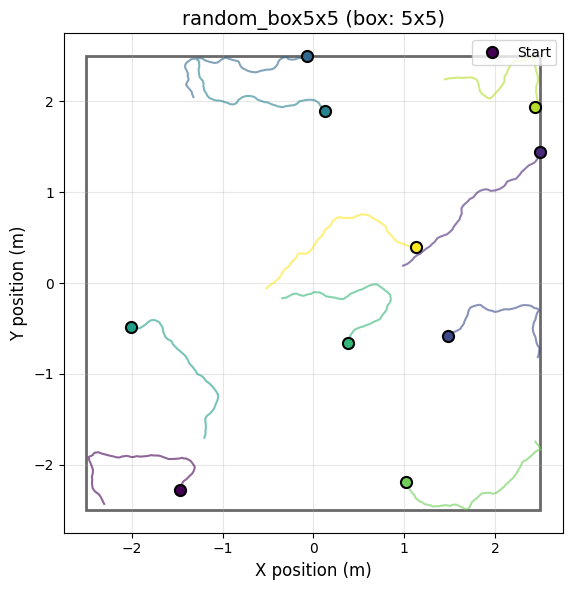

In [2]:
# Visualize validation dataset trajectories
import os
import json
import pickle
import matplotlib.pyplot as plt
from DataHandling import TrajectoryGenerator

validation_path = "dataset/validation"
generator = TrajectoryGenerator()

# Get all validation dataset directories
dataset_dirs = sorted([
    d for d in os.listdir(validation_path)
    if os.path.isdir(os.path.join(validation_path, d))
])

for dataset_name in dataset_dirs:
    dataset_path = os.path.join(validation_path, dataset_name)
    
    # Load metadata to get box dimensions
    with open(os.path.join(dataset_path, 'metadata.json'), 'r') as f:
        metadata = json.load(f)
    
    box_width = metadata['box_width']
    box_height = metadata['box_height']
    
    # Load first batch of trajectories
    with open(os.path.join(dataset_path, 'batch_00000.pkl'), 'rb') as f:
        positions = pickle.load(f)
    
    # Visualize 5 trajectories
    fig, ax = generator.visualize_trajectories(
        positions,
        box_width=box_width,
        box_height=box_height,
        num_trajectories=10,
        show_end=False,
        title=f"{dataset_name} (box: {box_width}x{box_height})",
        figsize=(6, 6)
    )
    plt.show()